In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('data_science_job.csv')

In [3]:
df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,20.0,NaN,NaN,36.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,47.0,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5.0,NaN,NaN,83.0,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,0.0,NaN,Pvt Ltd,52.0,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,20.0,50-99,Funded Startup,8.0,0.0


In [4]:
df.isnull().mean()

enrollee_id               0.000000
city                      0.000000
city_development_index    0.025003
gender                    0.235306
relevent_experience       0.000000
enrolled_university       0.020148
education_level           0.024011
major_discipline          0.146832
experience                0.003393
company_size              0.309949
company_type              0.320493
training_hours            0.039983
target                    0.000000
dtype: float64

In [5]:
cca_cols = [
    var for var in df.columns
    if df[var].isnull().mean()< 0.05
    and
    df[var].isnull().mean()>0
]

cca_cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [6]:
df[cca_cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
929,0.698,Full time course,Graduate,3.0,NaN
5346,0.624,no_enrollment,Graduate,4.0,166.0
13853,0.884,Part time course,Masters,10.0,7.0
6903,0.866,Full time course,Graduate,6.0,18.0
13768,0.780,no_enrollment,Graduate,20.0,138.0


In [7]:
len(df[cca_cols].dropna())/len(df)

0.8968577095730244

In [8]:
new_df = df[cca_cols].dropna()

array([[<Axes: title={'center': 'city_development_index'}>,
        <Axes: title={'center': 'experience'}>],
       [<Axes: title={'center': 'training_hours'}>, <Axes: >]],
      dtype=object)

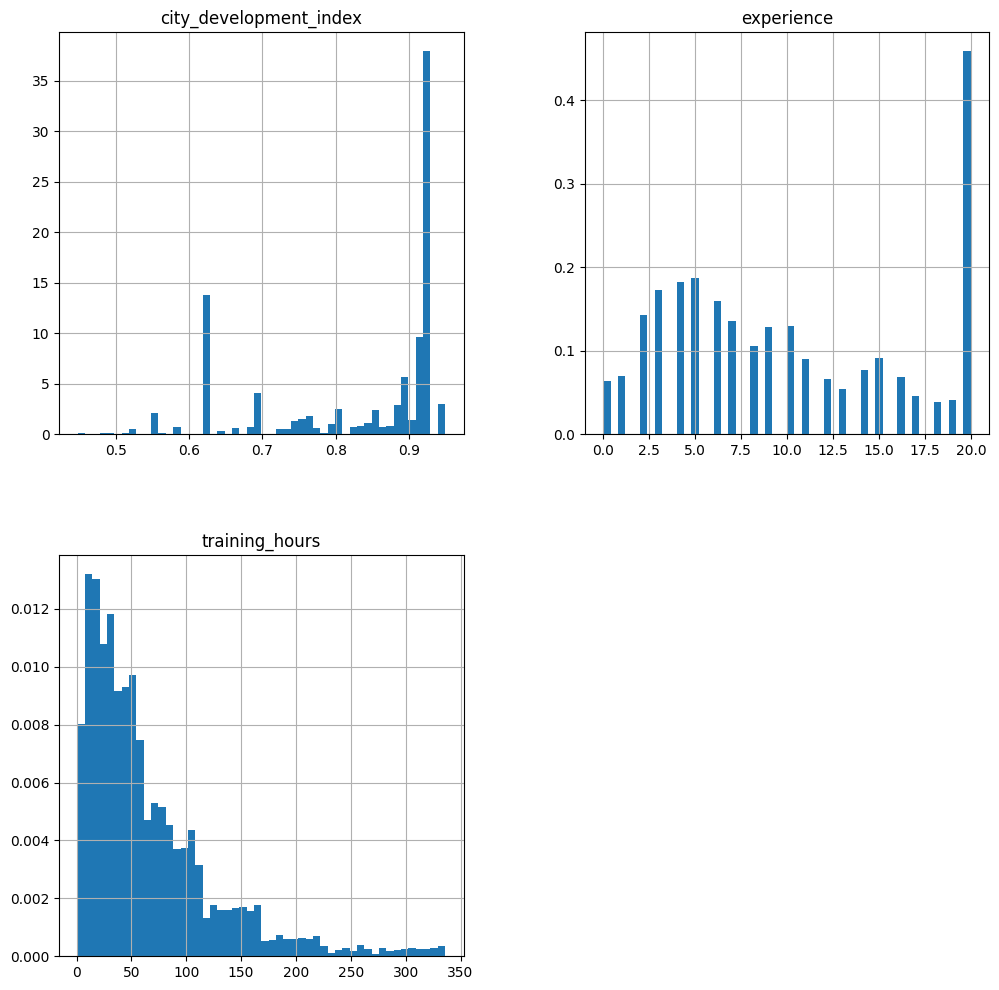

In [9]:
new_df.hist(bins= 50, density = True, figsize =(12,12))


### 1. Histogram Comparison for training_hours

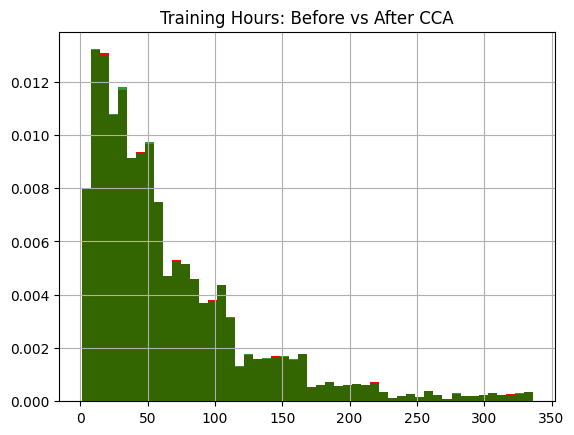

In [10]:
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure()

# Create axis
ax = fig.add_subplot(111)

# Original data distribution
df['training_hours'].hist(
    bins=50,
    ax=ax,
    density=True,
    color='red'
)

# Distribution after CCA
new_df['training_hours'].hist(
    bins=50,
    ax=ax,
    density=True,
    color='green',
    alpha=0.8   # transparency
)

plt.title('Training Hours: Before vs After CCA')
plt.show()

### Density Plot Comparison for training_hours

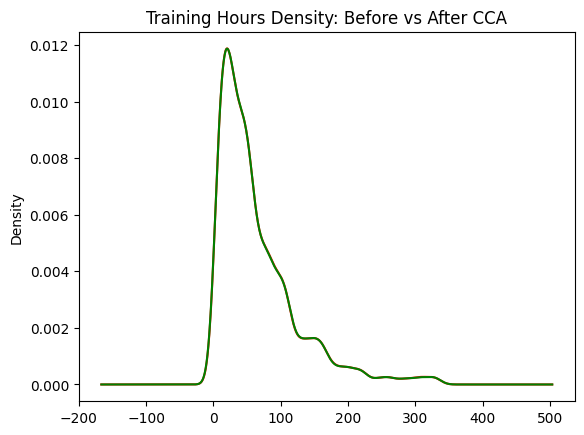

In [11]:
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure()

# Original data density
df['training_hours'].plot.density(
    color='red'
)

# Density after CCA
new_df['training_hours'].plot.density(
    color='green'
)

plt.title('Training Hours Density: Before vs After CCA')
plt.show()

### Histogram Comparison for city_development_index

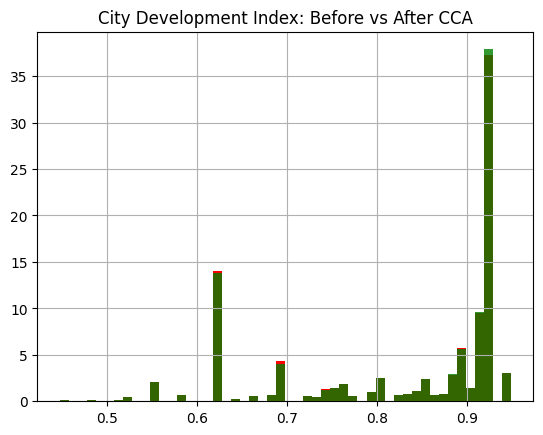

In [12]:
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure()

# Create axis
ax = fig.add_subplot(111)

# Original data
df['city_development_index'].hist(
    bins=50,
    ax=ax,
    density=True,
    color='red'
)

# Data after CCA
new_df['city_development_index'].hist(
    bins=50,
    ax=ax,
    density=True,
    color='green',
    alpha=0.8
)

plt.title('City Development Index: Before vs After CCA')
plt.show()

### Density Plot Comparison for city_development_index

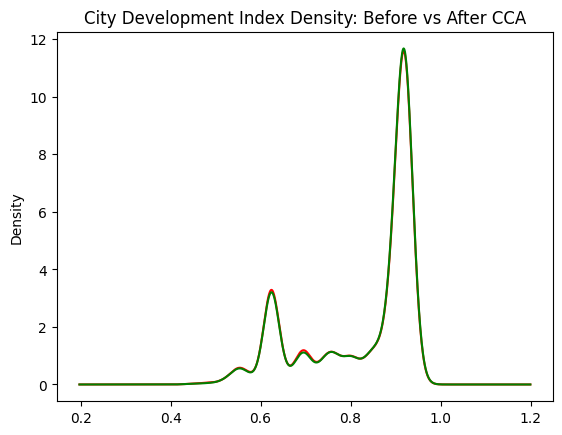

In [13]:
import matplotlib.pyplot as plt

# Create figure
fig = plt.figure()

# Original distribution
df['city_development_index'].plot.density(
    color='red'
)

# Distribution after CCA
new_df['city_development_index'].plot.density(
    color='green'
)

plt.title('City Development Index Density: Before vs After CCA')
plt.show()

### Step 1: Create Dataset After CCA

In [14]:
# Keep only selected columns and remove rows with missing values

new_df = df[cca_cols].dropna()

In [15]:
len(df[cca_cols].dropna()) / len(df)

0.8968577095730244

### Check Category Counts Before CCA

In [16]:
# Count observations in each category

df['enrolled_university'].value_counts()

enrolled_university
no_enrollment       13817
Full time course     3757
Part time course     1198
Name: count, dtype: int64

### Compare Category Percentages Before and After CCA

In [17]:
# Create comparison table

temp = pd.concat([

    # Category percentages in original dataset
    df['enrolled_university'].value_counts() / len(df),

    # Category percentages after CCA
    new_df['enrolled_university'].value_counts() / len(new_df)

], axis=1)

In [18]:
temp = pd.concat([
    df['enrolled_university'].value_counts() / len(df),
    new_df['enrolled_university'].value_counts() / len(new_df)
], axis=1)
temp.columns = ['original', 'cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.735188
Full time course,0.196106,0.200733
Part time course,0.062533,0.064079


### Interview Answer

After applying Complete Case Analysis, always compare:

Numerical variables → Histogram / Density Plot
Categorical variables → Percentage of observations per category (value_counts(normalize=True))

to verify that the distribution remains similar before and after removing missing observations.